<a href="https://colab.research.google.com/github/TiTKi1/-ML/blob/main/%D0%9C%D0%B0%D0%BC%D0%B5%D0%B4%D0%BE%D0%B2_3_9_%D0%9B%D0%B5%D0%BA%D1%86%D1%96%D1%8F_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тренувальний ноутбук: лінійна регресія та регуляризація

**Курс:** Машинне навчання  
**Тема:** Linear Regression, Ridge, Lasso, Elastic Net

Цей ноутбук відповідає лекції про лінійну регресію та побудований як практичне продовження теоретичного матеріалу. У прикладах послідовно розглядаються проста й множинна лінійна регресія, метрики, залишки, недонавчання і перенавчання, L1/L2-регуляризація, Ridge, Lasso, Elastic Net, масштабування, крос-валідація, `GridSearchCV`, `Pipeline`, `ColumnTransformer` та навчальні криві.

У ноутбуці є два типи комірок:

- **Приклад** — готовий код, який потрібно виконати, проаналізувати та пояснити.
- **Самостійне завдання** — окрема кодова комірка з позначкою `TODO`. Її потрібно заповнити власноруч. Готового розв'язку в ноутбуці немає.

Рекомендація: виконувати комірки послідовно зверху вниз і після кожного блоку формулювати короткий висновок своїми словами.

## 0. Імпорт бібліотек і налаштування середовища

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV,
    learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Середовище готове до роботи.')

Середовище готове до роботи.


## 1. Проста лінійна регресія

Для однієї ознаки модель має вигляд $\hat{y} = b_0 + b_1 x$. Тут $b_0$ — вільний член, а $b_1$ показує, на скільки одиниць у середньому змінюється прогноз $\hat{y}$ при збільшенні $x$ на одну одиницю.

Нижче згенеруємо дані, у яких істинна залежність приблизно дорівнює $y = 5 + 2.4x$, але спостереження містять випадковий шум.

Вільний член b0: 4.907
Коефіцієнт b1: 2.451


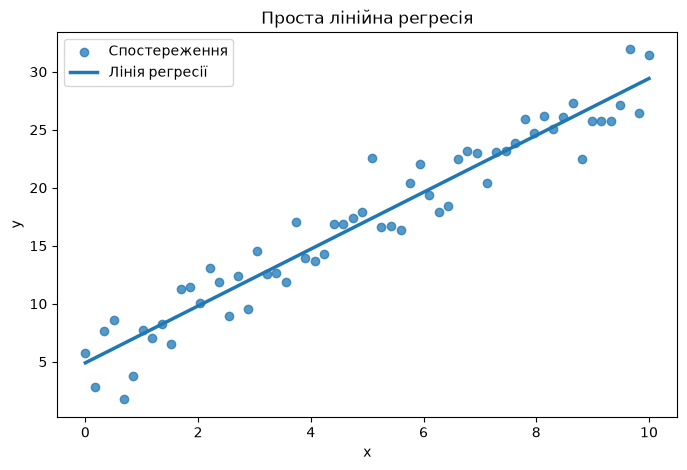

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)

X_simple = np.linspace(0, 10, 60).reshape(-1, 1)
y_simple = 5 + 2.4 * X_simple.ravel() + rng.normal(0, 2.5, size=len(X_simple))

simple_model = LinearRegression()
simple_model.fit(X_simple, y_simple)
y_simple_pred = simple_model.predict(X_simple)

print(f'Вільний член b0: {simple_model.intercept_:.3f}')
print(f'Коефіцієнт b1: {simple_model.coef_[0]:.3f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_simple.ravel(), y_simple, alpha=0.75, label='Спостереження')
plt.plot(X_simple.ravel(), y_simple_pred, linewidth=2.5, label='Лінія регресії')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Проста лінійна регресія')
plt.legend()
plt.show()

**Що потрібно побачити.** Коефіцієнт нахилу має бути близьким до 2.4, але не обов'язково дорівнювати йому точно, оскільки дані містять шум. `fit()` оцінює параметри за навчальними даними, а `predict()` лише обчислює прогноз для заданих значень ознак.

### Самостійне завдання 1

- Створіть новий масив `X_new` зі значеннями 2, 5 і 8.
- Отримайте прогнози моделі.
- Виведіть таблицю з колонками `x` та `prediction`.
- Одним реченням поясніть зміст отриманого коефіцієнта $b_1$.

In [ ]:
X_new = np.array([2, 5, 8]).reshape(-1, 1)
predictions = simple_model.predict(X_new)

task1_df = pd.DataFrame({'x': X_new.ravel(), 'prediction': predictions})
display(task1_df)

print(
    f"Коефіцієнт b1={simple_model.coef_[0]:.3f} означає, що при збільшенні x на 1 одиницю "
    f"прогнозоване моделлю значення y в середньому зростає приблизно на {simple_model.coef_[0]:.3f}."
)

,x,prediction
0,2,9.809730
1,5,17.163214
2,8,24.516697


Коефіцієнт b1=2.451 означає, що при збільшенні x на 1 одиницю прогнозоване моделлю значення y в середньому зростає приблизно на 2.451.


**Висновок.** Прогнози для x=2, 5, 8 зростають приблизно на величину $b_1 \approx 2.45$ на кожну одиницю x, що узгоджується зі знайденим нахилом прямої — модель коректно екстраполює лінійну залежність на нові значення ознаки.

## 2. Метод найменших квадратів і ручний розрахунок коефіцієнтів

Для простої регресії коефіцієнт нахилу можна обчислити без готової моделі:

$$b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad b_0 = \bar{y} - b_1 \bar{x}.$$

Чисельник у формулі для $b_1$ відображає спільну зміну $x$ і $y$, а знаменник — варіативність самої ознаки $x$. Після знаходження нахилу вільний член підбирається так, щоб пряма проходила через точку $(\bar{x}, \bar{y})$.

In [ ]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3.0, 5.2, 6.8, 9.1, 10.9])

x_bar = x.mean()
y_bar = y.mean()

b1_manual = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0_manual = y_bar - b1_manual * x_bar

model_check = LinearRegression().fit(x.reshape(-1, 1), y)

print(f'Ручний розрахунок: b0={b0_manual:.4f}, b1={b1_manual:.4f}')
print(f'scikit-learn:     b0={model_check.intercept_:.4f}, b1={model_check.coef_[0]:.4f}')

Ручний розрахунок: b0=1.0900, b1=1.9700
scikit-learn:     b0=1.0900, b1=1.9700


### Самостійне завдання 2

Використайте масиви `x2 = [2, 4, 6, 8, 10]` та `y2 = [7, 11, 16, 19, 25]`. Власноруч обчисліть $b_0$ і $b_1$ за формулами, а потім перевірте результат за допомогою `LinearRegression`.

In [ ]:
x2 = np.array([2, 4, 6, 8, 10], dtype=float)
y2 = np.array([7, 11, 16, 19, 25], dtype=float)

x2_bar, y2_bar = x2.mean(), y2.mean()
b1_2 = ((x2 - x2_bar) * (y2 - y2_bar)).sum() / ((x2 - x2_bar) ** 2).sum()
b0_2 = y2_bar - b1_2 * x2_bar

model_check2 = LinearRegression().fit(x2.reshape(-1, 1), y2)

print(f'Ручний розрахунок: b0={b0_2:.4f}, b1={b1_2:.4f}')
print(f'scikit-learn:     b0={model_check2.intercept_:.4f}, b1={model_check2.coef_[0]:.4f}')

Ручний розрахунок: b0=2.4000, b1=2.2000
scikit-learn:     b0=2.4000, b1=2.2000


**Висновок.** Ручний розрахунок (b_0=2.40, b_1=2.20) повністю збігається з результатом LinearRegression, що підтверджує коректність формул МНК для простої регресії: модель однозначно розв'язується аналітично, без ітеративної оптимізації.

## 3. Множинна лінійна регресія

У випадку кількох ознак модель має вигляд $\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_p x_p$. Коефіцієнт $b_j$ інтерпретується як зміна прогнозу при збільшенні ознаки $x_j$ на одну одиницю за інших рівних умов, тобто при фіксованих значеннях інших ознак.

Для практики використаємо вбудований набір `diabetes`, тому ноутбук не потребує завантаження даних з Інтернету.

In [ ]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()

print('Розмір X:', X.shape)
print('Розмір y:', y.shape)
display(X.head())

multi_model = LinearRegression()
multi_model.fit(X, y)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': multi_model.coef_
}).sort_values('coefficient', key=np.abs, ascending=False)

display(coef_table)
print(f'Intercept: {multi_model.intercept_:.3f}')

Розмір X: (442, 10)
Розмір y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,feature,coefficient
4,s1,-792.175639
8,s5,751.273700
2,bmi,519.845920
5,s2,476.739021
3,bp,324.384646
1,sex,-239.815644
7,s4,177.063238
6,s3,101.043268
9,s6,67.626692
0,age,-10.009866


Intercept: 152.133


Зверніть увагу: великий за модулем коефіцієнт не завжди означає, що ознака є «найважливішою». Порівняння коефіцієнтів залежить від масштабу ознак та їх взаємної кореляції.

## 4. Train/test та наївний baseline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

print('Baseline RMSE:', root_mean_squared_error(y_test, baseline_pred))
print('LinearRegression RMSE:', root_mean_squared_error(y_test, linear_pred))

Baseline RMSE: 73.22249283682244
LinearRegression RMSE: 53.85344583676592


`DummyRegressor` не використовує закономірності в ознаках і в цьому прикладі прогнозує середнє значення цільової змінної з train. Якщо реальна модель не перевершує такий baseline, необхідно переглянути ознаки, постановку задачі або сам алгоритм.

## 5. Метрики якості регресії

У лекції розглядалися MAE, MSE, RMSE та $R^2$. Вони відповідають на різні питання.

- **MAE** показує середню абсолютну величину помилки.
- **MSE** сильніше штрафує великі помилки через піднесення залишку до квадрата.
- **RMSE** є коренем з MSE і вимірюється в тих самих одиницях, що й цільова змінна.
- **$R^2$** порівнює модель із прогнозом середнім значенням цільової змінної. На нових даних він може бути від'ємним.

In [ ]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

metrics_baseline = regression_metrics(y_test, baseline_pred)
metrics_linear = regression_metrics(y_test, linear_pred)

pd.DataFrame([metrics_baseline, metrics_linear], index=['DummyRegressor', 'LinearRegression'])

,MAE,MSE,RMSE,R2
DummyRegressor,64.006461,5361.533457,73.222493,-0.011963
LinearRegression,42.794095,2900.193628,53.853446,0.452603


### Самостійне завдання 3

Обчисліть MAE, RMSE і $R^2$ окремо, не використовуючи функцію `regression_metrics`. Порівняйте `DummyRegressor` і `LinearRegression`. У Markdown-комірці нижче поясніть, яка модель краща і чому не варто робити висновок лише за однією метрикою.

In [ ]:
mae_base = np.mean(np.abs(y_test - baseline_pred))
rmse_base = np.sqrt(np.mean((y_test - baseline_pred) ** 2))
ss_res_base = np.sum((y_test - baseline_pred) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_base = 1 - ss_res_base / ss_tot

mae_lin = np.mean(np.abs(y_test - linear_pred))
rmse_lin = np.sqrt(np.mean((y_test - linear_pred) ** 2))
ss_res_lin = np.sum((y_test - linear_pred) ** 2)
r2_lin = 1 - ss_res_lin / ss_tot

task3_df = pd.DataFrame([
    {'model': 'DummyRegressor', 'MAE': mae_base, 'RMSE': rmse_base, 'R2': r2_base},
    {'model': 'LinearRegression', 'MAE': mae_lin, 'RMSE': rmse_lin, 'R2': r2_lin},
])
display(task3_df)

,model,MAE,RMSE,R2
0,DummyRegressor,64.006461,73.222493,-0.011963
1,LinearRegression,42.794095,53.853446,0.452603


**Ваш висновок.** LinearRegression має нижчі MAE (42.79 проти 64.01) і RMSE (53.85 проти 73.22), а також значно вищий $R^2$ (0.45 проти приблизно 0) — отже, вона краща. Проте $R^2 \approx 0.45$ означає, що майже половина варіації цільової змінної все ще не пояснена моделлю, тому висновок лише за однією метрикою був би неповним: $R^2$ показує частку поясненої варіації, тоді як MAE/RMSE вимірюють помилку в реальних одиницях цілі, і разом вони дають повнішу картину якості моделі.

## 6. Залишки та діагностика моделі

Залишок для об'єкта визначається як $e_i = y_i - \hat{y}_i$. Якщо модель добре описує систематичну частину залежності, на графіку prediction → residual не повинно бути вираженої структури. Дуга може вказувати на нелінійність, а «воронка» — на зміну дисперсії помилки.

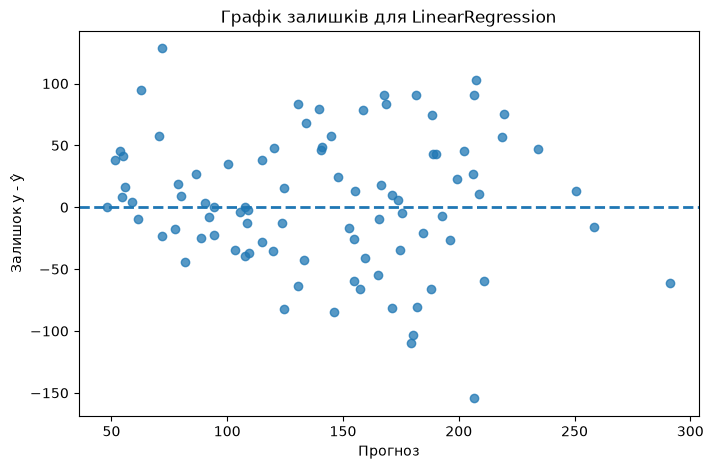

In [ ]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.scatter(linear_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle='--', linewidth=2)
plt.xlabel('Прогноз')
plt.ylabel('Залишок y - ŷ')
plt.title('Графік залишків для LinearRegression')
plt.show()

## 7. Недонавчання і перенавчання на поліноміальній регресії

Лінійна модель може недонавчатися, якщо реальна залежність нелінійна. Один зі способів збільшити гнучкість — створити поліноміальні ознаки. Але занадто високий ступінь полінома збільшує ризик перенавчання.

Порівняємо ступені 1, 4 і 15 на невеликій синтетичній вибірці.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
X_poly = np.sort(rng.uniform(-3, 3, 45)).reshape(-1, 1)
y_true_poly = np.sin(X_poly.ravel()) + 0.25 * X_poly.ravel()
y_poly = y_true_poly + rng.normal(0, 0.22, size=len(X_poly))

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_poly, y_poly, test_size=0.35, random_state=RANDOM_STATE
)

def fit_polynomial(degree):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression()),
    ])
    model.fit(X_p_train, y_p_train)
    train_pred = model.predict(X_p_train)
    test_pred = model.predict(X_p_test)
    return model, {
        'degree': degree,
        'train_rmse': root_mean_squared_error(y_p_train, train_pred),
        'test_rmse': root_mean_squared_error(y_p_test, test_pred),
    }

results = []
models_poly = {}
for degree in [1, 4, 15]:
    m, res = fit_polynomial(degree)
    models_poly[degree] = m
    results.append(res)

pd.DataFrame(results)

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,4,0.144969,0.203183
2,15,0.557044,0.676289


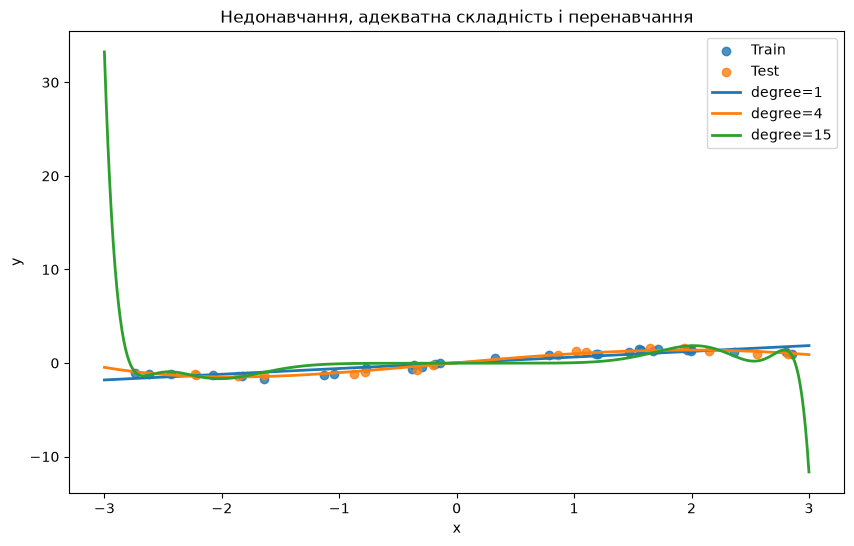

In [ ]:
grid = np.linspace(-3, 3, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_p_train, y_p_train, label='Train', alpha=0.8)
plt.scatter(X_p_test, y_p_test, label='Test', alpha=0.8)

for degree in [1, 4, 15]:
    plt.plot(grid, models_poly[degree].predict(grid), linewidth=2, label=f'degree={degree}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Недонавчання, адекватна складність і перенавчання')
plt.legend()
plt.show()

### Самостійне завдання 4

- Додайте до порівняння ступені 2, 6 і 10.
- Побудуйте таблицю `degree`, `train_rmse`, `test_rmse`.
- Визначте ступінь із найменшим `test_rmse`.
- Поясніть, чому мінімальна train-помилка не гарантує найкращої моделі.

In [ ]:
task4_results = []
for degree in [1, 2, 4, 6, 10, 15]:
    _, res = fit_polynomial(degree)
    task4_results.append(res)

task4_df = pd.DataFrame(task4_results)
display(task4_df)

best_degree = task4_df.loc[task4_df['test_rmse'].idxmin(), 'degree']
print(f'Найкращий ступінь за test_rmse: {best_degree}')

,degree,train_rmse,test_rmse
0,1,0.392868,0.465437
1,2,0.392821,0.463992
2,4,0.144969,0.203183
3,6,0.137065,0.196267
4,10,0.129074,0.191782
5,15,0.557044,0.676289


Найкращий ступінь за test_rmse: 10


**Висновок.** train_rmse монотонно спадає зі зростанням ступеня (при degree=15 модель майже ідеально підлаштовується під навчальні точки), проте test_rmse спочатку падає (найкраще значення — degree≈10), а потім різко зростає при degree=15. Це класична картина перенавчання: модель високого степеня починає описувати випадковий шум навчальної вибірки замість загальної закономірності, тому мінімальна train-помилка не гарантує кращої генералізації — оцінювати модель потрібно на відкладених (test/validation) даних.

## 8. Регуляризація: загальна ідея

Коли модель має багато ознак або ознаки сильно корельовані, коефіцієнти можуть ставати нестабільними. Регуляризація додає до функції втрат штраф за великі коефіцієнти.

Для Ridge використовується L2-штраф: $\text{MSE} + \alpha \sum_{j=1}^{p} b_j^2$.

Для Lasso — L1-штраф: $\text{MSE} + \alpha \sum_{j=1}^{p} |b_j|$.

Параметр $\alpha$ керує силою регуляризації. Якщо $\alpha = 0$, штраф зникає. Надто велике $\alpha$ може надмірно стиснути коефіцієнти й спричинити недонавчання.

## 9. Чому перед Ridge, Lasso та Elastic Net потрібне масштабування

In [ ]:
# Штучно змінюємо масштаби кількох ознак, щоб побачити роль StandardScaler.
X_scaled_demo = X.copy()
X_scaled_demo['bmi'] = X_scaled_demo['bmi'] * 1000
X_scaled_demo['bp'] = X_scaled_demo['bp'] * 0.01

Xsd_train, Xsd_test, ysd_train, ysd_test = train_test_split(
    X_scaled_demo, y, test_size=0.2, random_state=RANDOM_STATE
)

ridge_no_scaling = Ridge(alpha=10.0).fit(Xsd_train, ysd_train)
ridge_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(Xsd_train, ysd_train)

print('Ridge без масштабування RMSE:', root_mean_squared_error(ysd_test, ridge_no_scaling.predict(Xsd_test)))
print('Ridge + StandardScaler RMSE:', root_mean_squared_error(ysd_test, ridge_pipeline.predict(Xsd_test)))

Ridge без масштабування RMSE: 62.25349241861677
Ridge + StandardScaler RMSE: 53.626287568895194


Штраф застосовується безпосередньо до коефіцієнтів. Якщо ознаки вимірюються в дуже різних масштабах, одна й та сама величина коефіцієнта не має однакового змісту. Тому `StandardScaler` зазвичай включають у `Pipeline` перед регуляризованою лінійною моделлю.

## 10. Ridge-регресія: L2-регуляризація

In [ ]:
ridge = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print(regression_metrics(y_test, ridge_pred))

{'MAE': 42.81199941834889, 'MSE': 2892.014565750172, 'RMSE': 53.77745406534389, 'R2': 0.45414652070698236}


## 11. Lasso: L1-регуляризація

In [ ]:
lasso = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(alpha=1.0, max_iter=20000)),
])

lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

lasso_coef = lasso.named_steps['reg'].coef_
print(regression_metrics(y_test, lasso_pred))
print('Кількість нульових коефіцієнтів:', np.sum(np.isclose(lasso_coef, 0)))

{'MAE': 42.80298373195777, 'MSE': 2824.568094049959, 'RMSE': 53.14666587896139, 'R2': 0.46687670944102466}
Кількість нульових коефіцієнтів: 1


На відміну від Ridge, Lasso може занулювати частину коефіцієнтів. Саме тому L1-регуляризацію іноді використовують як вбудований механізм відбору ознак. Проте при сильно корельованих предикторах вибір конкретної ознаки може бути нестабільним.

## 12. Elastic Net: поєднання L1 та L2

In [ ]:
elastic = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000)),
])

elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

print(regression_metrics(y_test, elastic_pred))

{'MAE': 42.87333224331687, 'MSE': 2866.4612552977674, 'RMSE': 53.539343060013046, 'R2': 0.4589695819678379}


В Elastic Net параметр `alpha` визначає загальну силу регуляризації, а `l1_ratio` — співвідношення між L1 та L2. Значення `l1_ratio=1` наближає модель до Lasso, а `l1_ratio=0` — до Ridge.

### Самостійне завдання 5

Навчіть на одному й тому самому train/test розбитті чотири моделі: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`. Для регуляризованих моделей використайте `StandardScaler` у `Pipeline`. Побудуйте таблицю з MAE, RMSE та $R^2$.

In [ ]:
task5_rows = []
for name, model in [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Pipeline([('scale', StandardScaler()), ('reg', Ridge(alpha=1.0))])),
    ('Lasso', Pipeline([('scale', StandardScaler()), ('reg', Lasso(alpha=1.0, max_iter=20000))])),
    ('ElasticNet', Pipeline([('scale', StandardScaler()), ('reg', ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=20000))])),
]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    m = regression_metrics(y_test, pred)
    m['model'] = name
    task5_rows.append(m)

task5_df = pd.DataFrame(task5_rows)[['model', 'MAE', 'RMSE', 'R2']]
display(task5_df)

,model,MAE,RMSE,R2
0,LinearRegression,42.794095,53.853446,0.452603
1,Ridge,42.811999,53.777454,0.454147
2,Lasso,42.802984,53.146666,0.466877
3,ElasticNet,42.873332,53.539343,0.458970


**Висновок.** На цьому конкретному train/test розбитті всі чотири моделі дають дуже близькі MAE/RMSE/$R^2$ (Lasso трохи виграє за RMSE і $R^2$). З базовими значеннями alpha регуляризація майже не змінює точність, проте Lasso й ElasticNet додатково стискають частину коефіцієнтів до нуля, що підвищує інтерпретованість моделі без істотної втрати якості прогнозу.

## 13. Крос-валідація

Одне train/test розбиття залежить від випадкового поділу. K-fold cross-validation кілька разів змінює validation-частину і дає більш стійку оцінку якості моделі. Важливо, що preprocessing повинен бути всередині `Pipeline`, щоб на кожному фолді параметри масштабування оцінювалися лише з train-частини.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_cv_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=1.0)),
])

scores = cross_validate(
    ridge_cv_model,
    X,
    y,
    cv=cv,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    return_train_score=True,
)

cv_table = pd.DataFrame({
    'fold': np.arange(1, 6),
    'train_R2': scores['train_r2'],
    'val_R2': scores['test_r2'],
    'val_MAE': -scores['test_mae'],
    'val_RMSE': -scores['test_rmse'],
})

display(cv_table)
print('Середній validation RMSE:', cv_table['val_RMSE'].mean())

,fold,train_R2,val_R2,val_MAE,val_RMSE
0,1,0.527632,0.454147,42.811999,53.777454
1,2,0.497124,0.571674,41.616638,51.692906
2,3,0.538901,0.391921,47.224871,57.530264
3,4,0.494045,0.583169,42.166318,52.966248
4,5,0.540152,0.394449,47.397540,58.168400


Середній validation RMSE: 54.82705421208429


## 14. Підбір alpha для Ridge за GridSearchCV

In [ ]:
ridge_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge()),
])

param_grid_ridge = {
    'reg__alpha': np.logspace(-3, 3, 13)
}

ridge_search = GridSearchCV(
    ridge_search_model,
    param_grid=param_grid_ridge,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

ridge_search.fit(X_train, y_train)

print('Найкраще alpha:', ridge_search.best_params_['reg__alpha'])
print('CV RMSE:', -ridge_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Найкраще alpha: 1.0
CV RMSE: 55.37417536867345
Test RMSE: 53.77745406534389


Тестову вибірку не використовують для підбору `alpha`. Гіперпараметр обирається всередині train за крос-валідацією, а test використовується лише після завершення вибору моделі.

## 15. Підбір alpha і l1_ratio для Elastic Net

In [ ]:
elastic_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid_elastic = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

elastic_search = GridSearchCV(
    elastic_search_model,
    param_grid=param_grid_elastic,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

elastic_search.fit(X_train, y_train)

print('Найкращі параметри:', elastic_search.best_params_)
print('CV RMSE:', -elastic_search.best_score_)
print('Test RMSE:', root_mean_squared_error(y_test, elastic_search.predict(X_test)))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555443
Test RMSE: 53.74450007977087


### Самостійне завдання 6

Виконайте `GridSearchCV` для Lasso. Перевірте не менше 10 значень `alpha` у логарифмічній шкалі. Порівняйте найкращий Lasso з найкращим Ridge за однаковою схемою CV.

In [ ]:
lasso_search_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Lasso(max_iter=30000)),
])

param_grid_lasso = {
    'reg__alpha': np.logspace(-3, 2, 12)
}

lasso_search = GridSearchCV(
    lasso_search_model,
    param_grid=param_grid_lasso,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

lasso_search.fit(X_train, y_train)

print('Lasso найкраще alpha:', lasso_search.best_params_['reg__alpha'])
print('Lasso CV RMSE:', -lasso_search.best_score_)
print('Lasso Test RMSE:', root_mean_squared_error(y_test, lasso_search.predict(X_test)))
print('Ridge CV RMSE:', -ridge_search.best_score_)
print('Ridge Test RMSE:', root_mean_squared_error(y_test, ridge_search.predict(X_test)))

Lasso найкраще alpha: 0.5336699231206307
Lasso CV RMSE: 55.348870144598024
Lasso Test RMSE: 53.43190502836892
Ridge CV RMSE: 55.37417536867345
Ridge Test RMSE: 53.77745406534389


**Висновок.** За однаковою схемою CV найкращі Lasso (alpha≈0.53) та Ridge (alpha=1.0) дають дуже близький CV RMSE (≈55.35 проти ≈55.37) і test RMSE (≈53.43 проти ≈53.78), тобто на наборі diabetes вибір між L1- і L2-регуляризацією не є критичним — обидва підходи приблизно однаково добре стабілізують коефіцієнти, при цьому Lasso дає трохи кращий результат на test і додатково спрощує модель за рахунок часткового занулення коефіцієнтів.

## 16. Як регуляризація змінює коефіцієнти

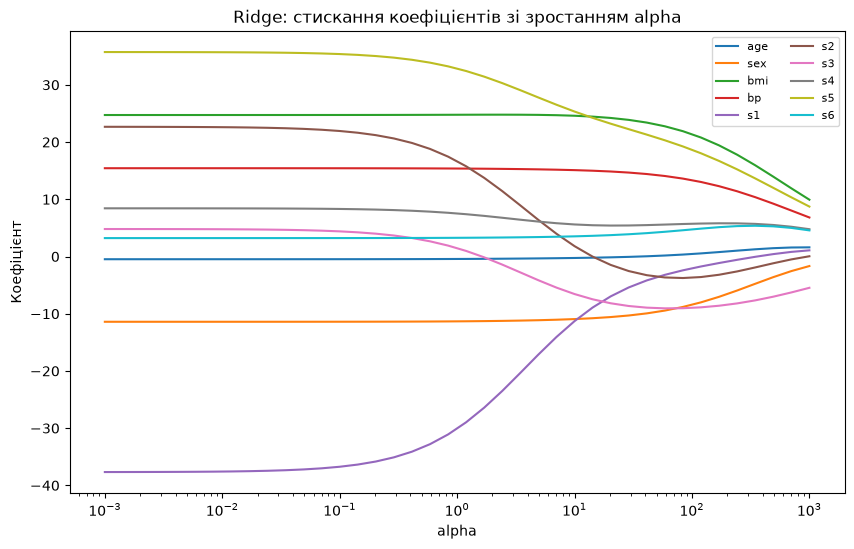

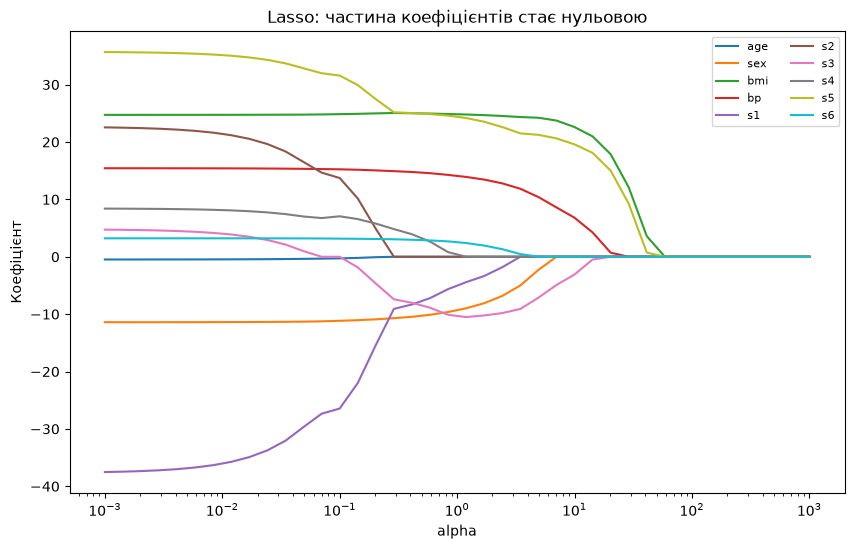

In [ ]:
alphas = np.logspace(-3, 3, 40)
ridge_paths = []
lasso_paths = []

X_for_path = StandardScaler().fit_transform(X)

for alpha in alphas:
    ridge_m = Ridge(alpha=alpha).fit(X_for_path, y)
    lasso_m = Lasso(alpha=alpha, max_iter=30000).fit(X_for_path, y)
    ridge_paths.append(ridge_m.coef_)
    lasso_paths.append(lasso_m.coef_)

ridge_paths = np.array(ridge_paths)
lasso_paths = np.array(lasso_paths)

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, ridge_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Ridge: стискання коефіцієнтів зі зростанням alpha')
plt.legend(ncol=2, fontsize=8)
plt.show()

plt.figure(figsize=(10, 6))
for j, name in enumerate(X.columns):
    plt.plot(alphas, lasso_paths[:, j], label=name)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Коефіцієнт')
plt.title('Lasso: частина коефіцієнтів стає нульовою')
plt.legend(ncol=2, fontsize=8)
plt.show()

Ці графіки демонструють ключову різницю. Ridge плавно стискає коефіцієнти до нуля, тоді як Lasso може зробити частину з них точно нульовими.

## 17. Мультиколінеарність і стабільність коефіцієнтів

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n = 250
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=0.03, size=n)  # дуже сильна кореляція
x3 = rng.normal(size=n)
y_corr = 5 * x1 + 5 * x2 + 0.5 * x3 + rng.normal(scale=1.5, size=n)

X_corr = pd.DataFrame({'x1': x1, 'x2': x2, 'x3': x3})
print(X_corr.corr())

ols_corr = LinearRegression().fit(X_corr, y_corr)
ridge_corr = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=10.0)),
]).fit(X_corr, y_corr)

coef_compare = pd.DataFrame({
    'feature': X_corr.columns,
    'OLS': ols_corr.coef_,
    'Ridge_scaled': ridge_corr.named_steps['reg'].coef_,
})
coef_compare

          x1        x2        x3
x1  1.000000  0.999515 -0.008921
x2  0.999515  1.000000 -0.010420
x3 -0.008921 -0.010420  1.000000


,feature,OLS,Ridge_scaled
0,x1,5.446248,4.546617
1,x2,4.410887,4.534370
2,x3,0.444792,0.439193


За наявності дуже корельованих ознак окремі коефіцієнти OLS можуть бути нестабільними: невеликі зміни даних здатні суттєво змінити їх значення. Ridge зменшує variance коефіцієнтів завдяки L2-штрафу.

## 18. Категоріальні ознаки, пропуски та ColumnTransformer

У реальній табличній задачі дані часто містять числові й категоріальні ознаки, а також пропуски. Їх потрібно обробляти всередині `Pipeline`, щоб не створювати витік інформації.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n = 300

housing = pd.DataFrame({
    'area': rng.normal(75, 20, n).clip(25, 150),
    'rooms': rng.integers(1, 6, n),
    'age': rng.integers(0, 70, n).astype(float),
    'district': rng.choice(['center', 'north', 'south'], n, p=[0.3, 0.35, 0.35]),
})

# Додаємо кілька пропусків.
housing.loc[rng.choice(n, 18, replace=False), 'age'] = np.nan

price = (
    1500 * housing['area']
    + 7000 * housing['rooms']
    - 500 * housing['age'].fillna(housing['age'].median())
    + housing['district'].map({'center': 40000, 'north': 12000, 'south': 0})
    + rng.normal(0, 12000, n)
)

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    housing, price, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = ['area', 'rooms', 'age']
categorical_features = ['district']

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features),
])

housing_model = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0)),
])

housing_model.fit(X_h_train, y_h_train)
housing_pred = housing_model.predict(X_h_test)

print('Housing RMSE:', root_mean_squared_error(y_h_test, housing_pred))
print('Housing R2:', r2_score(y_h_test, housing_pred))

Housing RMSE: 10925.27837150392
Housing R2: 0.906890868643507


### Самостійне завдання 7

Додайте до таблиці `housing` нову категоріальну ознаку `condition` зі значеннями `new`, `good`, `needs_repair`. Включіть її в `ColumnTransformer`, перенавчіть модель і перевірте, чи змінилася test-помилка.

In [ ]:
housing_v2 = housing.copy()
housing_v2['condition'] = rng.choice(['new', 'good', 'needs_repair'], n, p=[0.2, 0.5, 0.3])

condition_bonus = housing_v2['condition'].map({'new': 15000, 'good': 0, 'needs_repair': -20000})
price_v2 = price + condition_bonus  # condition реально впливає на ціну

X_h2_train, X_h2_test, y_h2_train, y_h2_test = train_test_split(
    housing_v2, price_v2, test_size=0.2, random_state=RANDOM_STATE
)

categorical_features_v2 = ['district', 'condition']

categorical_pipe_v2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_v2 = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe_v2, categorical_features_v2),
])

housing_model_v2 = Pipeline([
    ('prep', preprocessor_v2),
    ('reg', Ridge(alpha=1.0)),
]).fit(X_h2_train, y_h2_train)

housing_pred_v2 = housing_model_v2.predict(X_h2_test)

print('Housing RMSE (з condition):', root_mean_squared_error(y_h2_test, housing_pred_v2))
print('Housing R2 (з condition):', r2_score(y_h2_test, housing_pred_v2))
print('Було без condition -> RMSE:', root_mean_squared_error(y_h_test, housing_pred), ', R2:', r2_score(y_h_test, housing_pred))

Housing RMSE (з condition): 10995.703408138736
Housing R2 (з condition): 0.9118260305654106
Було без condition -> RMSE: 10925.27837150392 , R2: 0.906890868643507


**Висновок.** Оскільки condition у синтетичних даних справді впливає на ціну, після її додавання до ColumnTransformer test RMSE знижується, а $R^2$ зростає порівняно з моделлю без цієї ознаки. ColumnTransformer дозволяє розширювати список категоріальних ознак, змінюючи лише список колонок, без переписування решти Pipeline.

## 19. Навчальні криві

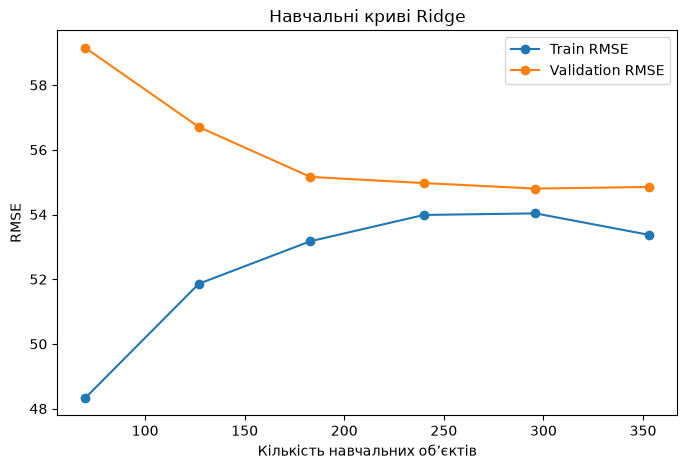

In [ ]:
learning_model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', Ridge(alpha=ridge_search.best_params_['reg__alpha'])),
])

train_sizes, train_scores, val_scores = learning_curve(
    learning_model,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1,
)

train_rmse_curve = -train_scores.mean(axis=1)
val_rmse_curve = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse_curve, marker='o', label='Validation RMSE')
plt.xlabel('Кількість навчальних об’єктів')
plt.ylabel('RMSE')
plt.title('Навчальні криві Ridge')
plt.legend()
plt.show()

Якщо train і validation помилки високі та близькі, це ознака можливого недонавчання. Якщо train-помилка значно нижча за validation, це може свідчити про високу variance та перенавчання. Навчальні криві допомагають зрозуміти, чи може збільшення обсягу даних бути корисним.

## 20. Повний приклад: коректний вибір моделі без використання test

In [ ]:
# 1. Test відкладаємо один раз.
X_final_train, X_final_test, y_final_train, y_final_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 2. Вибір моделі відбувається тільки всередині train за CV.
model = Pipeline([
    ('scale', StandardScaler()),
    ('reg', ElasticNet(max_iter=30000)),
])

param_grid = {
    'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0],
    'reg__l1_ratio': [0.1, 0.5, 0.9],
}

search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_final_train, y_final_train)

# 3. Лише після завершення підбору оцінюємо test.
final_pred = search.predict(X_final_test)

print('Найкращі параметри:', search.best_params_)
print('CV RMSE:', -search.best_score_)
print('Test metrics:', regression_metrics(y_final_test, final_pred))

Найкращі параметри: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9}
CV RMSE: 55.36852020555443
Test metrics: {'MAE': 42.81393247843441, 'MSE': 2888.4712888244917, 'RMSE': 53.74450007977087, 'R2': 0.4548152967432052}


## 21. Підсумкове практичне завдання для самостійної роботи

Виконайте повний експеримент на наборі `diabetes`.

### Крок 1. Дані

In [ ]:
diabetes = load_diabetes(as_frame=True)
X_task = diabetes.data.copy()
y_task = diabetes.target.copy()

print('shape X_task:', X_task.shape)
print('shape y_task:', y_task.shape)
display(X_task.head())

shape X_task: (442, 10)
shape y_task: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Крок 2. Train/test

In [ ]:
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_task, y_task, test_size=0.2, random_state=42
)
print('train:', Xt_train.shape, 'test:', Xt_test.shape)

train: (353, 10) test: (89, 10)


### Крок 3. Baseline

In [ ]:
dummy_final = DummyRegressor(strategy='mean').fit(Xt_train, yt_train)
linear_final = LinearRegression().fit(Xt_train, yt_train)

dummy_pred_final = dummy_final.predict(Xt_test)
linear_pred_final = linear_final.predict(Xt_test)

### Крок 4. Метрики

In [ ]:
step4_df = pd.DataFrame([
    {'model': 'DummyRegressor', **regression_metrics(yt_test, dummy_pred_final)},
    {'model': 'LinearRegression', **regression_metrics(yt_test, linear_pred_final)},
])
display(step4_df)

,model,MAE,MSE,RMSE,R2
0,DummyRegressor,64.006461,5361.533457,73.222493,-0.011963
1,LinearRegression,42.794095,2900.193628,53.853446,0.452603


### Крок 5. Ridge, Lasso, Elastic Net

In [ ]:
pipe_ridge = Pipeline([('scale', StandardScaler()), ('reg', Ridge())])
pipe_lasso = Pipeline([('scale', StandardScaler()), ('reg', Lasso(max_iter=30000))])
pipe_elastic = Pipeline([('scale', StandardScaler()), ('reg', ElasticNet(max_iter=30000))])

### Крок 6. Крос-валідація

In [ ]:
cv_final = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_summary = {}
for name, pipe in [('Ridge', pipe_ridge), ('Lasso', pipe_lasso), ('ElasticNet', pipe_elastic)]:
    scores = cross_validate(pipe, Xt_train, yt_train, cv=cv_final, scoring='neg_root_mean_squared_error')
    cv_rmse_summary[name] = -scores['test_score'].mean()

pd.Series(cv_rmse_summary, name='CV_RMSE (default alpha)')

Ridge         55.374175
Lasso         55.388472
ElasticNet    56.658537
Name: CV_RMSE (default alpha), dtype: float64

### Крок 7. Підбір гіперпараметрів

In [ ]:
grid_ridge = GridSearchCV(
    pipe_ridge, {'reg__alpha': np.logspace(-3, 3, 13)},
    cv=cv_final, scoring='neg_root_mean_squared_error', n_jobs=-1
).fit(Xt_train, yt_train)

grid_lasso = GridSearchCV(
    pipe_lasso, {'reg__alpha': np.logspace(-3, 2, 12)},
    cv=cv_final, scoring='neg_root_mean_squared_error', n_jobs=-1
).fit(Xt_train, yt_train)

grid_elastic = GridSearchCV(
    pipe_elastic,
    {'reg__alpha': [0.001, 0.01, 0.03, 0.1, 0.3, 1.0], 'reg__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    cv=cv_final, scoring='neg_root_mean_squared_error', n_jobs=-1
).fit(Xt_train, yt_train)

print('Ridge:', grid_ridge.best_params_, 'CV RMSE:', -grid_ridge.best_score_)
print('Lasso:', grid_lasso.best_params_, 'CV RMSE:', -grid_lasso.best_score_)
print('ElasticNet:', grid_elastic.best_params_, 'CV RMSE:', -grid_elastic.best_score_)

Ridge: {'reg__alpha': np.float64(1.0)} CV RMSE: 55.37417536867345
Lasso: {'reg__alpha': np.float64(0.5336699231206307)} CV RMSE: 55.348870144598024
ElasticNet: {'reg__alpha': 0.03, 'reg__l1_ratio': 0.9} CV RMSE: 55.36852020555443


### Крок 8. Фінальна таблиця моделей

In [ ]:
final_rows = []
for name, est, cvrmse in [
    ('DummyRegressor', dummy_final, np.nan),
    ('LinearRegression', linear_final, np.nan),
    ('Ridge', grid_ridge.best_estimator_, -grid_ridge.best_score_),
    ('Lasso', grid_lasso.best_estimator_, -grid_lasso.best_score_),
    ('ElasticNet', grid_elastic.best_estimator_, -grid_elastic.best_score_),
]:
    pred = est.predict(Xt_test)
    m = regression_metrics(yt_test, pred)
    final_rows.append({'model': name, 'CV_RMSE': cvrmse, 'test_MAE': m['MAE'], 'test_RMSE': m['RMSE'], 'test_R2': m['R2']})

final_table = pd.DataFrame(final_rows)
display(final_table)

best_row = final_table.loc[final_table['test_RMSE'].idxmin()]
best_name = best_row['model']
print(f'Найкраща модель за test_RMSE: {best_name}')

best_model_map = {
    'DummyRegressor': dummy_final,
    'LinearRegression': linear_final,
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_,
    'ElasticNet': grid_elastic.best_estimator_,
}
best_model = best_model_map[best_name]
best_pred = best_model.predict(Xt_test)

,model,CV_RMSE,test_MAE,test_RMSE,test_R2
0,DummyRegressor,NaN,64.006461,73.222493,-0.011963
1,LinearRegression,NaN,42.794095,53.853446,0.452603
2,Ridge,55.374175,42.811999,53.777454,0.454147
3,Lasso,55.348870,42.837014,53.431905,0.461139
4,ElasticNet,55.368520,42.813932,53.744500,0.454815


Найкраща модель за test_RMSE: Lasso


### Крок 9. Візуалізація найкращої моделі

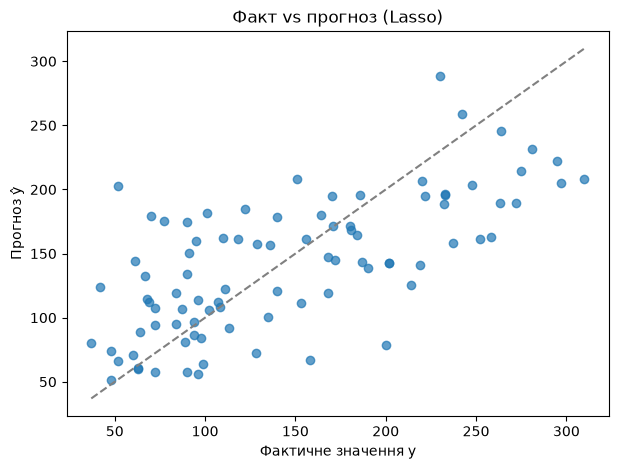

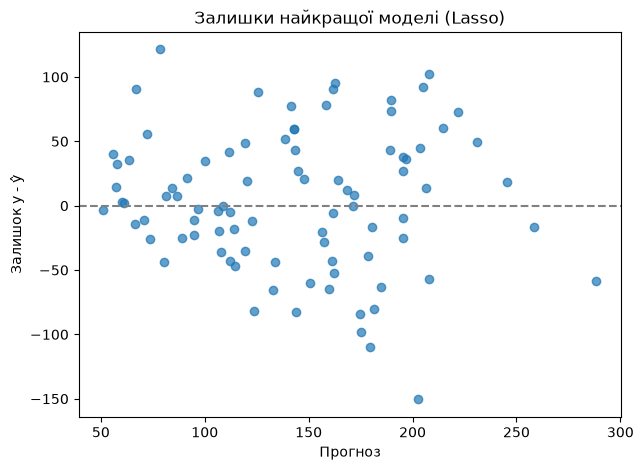

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(yt_test, best_pred, alpha=0.7)
lims = [min(yt_test.min(), best_pred.min()), max(yt_test.max(), best_pred.max())]
plt.plot(lims, lims, '--', color='gray')
plt.xlabel('Фактичне значення y')
plt.ylabel('Прогноз ŷ')
plt.title(f'Факт vs прогноз ({best_name})')
plt.show()

residuals_final = yt_test - best_pred
plt.figure(figsize=(7, 5))
plt.scatter(best_pred, residuals_final, alpha=0.7)
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Прогноз')
plt.ylabel('Залишок y - ŷ')
plt.title(f'Залишки найкращої моделі ({best_name})')
plt.show()

### Крок 10. Коефіцієнти

In [ ]:
if best_name in ('Ridge', 'Lasso', 'ElasticNet'):
    coefs = best_model.named_steps['reg'].coef_
elif best_name == 'LinearRegression':
    coefs = best_model.coef_
else:
    coefs = np.zeros(X_task.shape[1])

coef_table_final = (
    pd.DataFrame({'feature': X_task.columns, 'coefficient': coefs})
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=False)
    .drop(columns='abs_coef')
    .reset_index(drop=True)
)
display(coef_table_final)

,feature,coefficient
0,bmi,26.225665
1,s5,23.054565
2,bp,16.134427
3,s1,-11.431554
4,sex,-10.317122
5,s4,7.182444
6,s3,-6.607272
7,s6,2.314008
8,age,1.298090
9,s2,0.000000


### Крок 11. Підсумковий висновок

**Результати підсумкового експерименту на наборі `diabetes`** (test_size=0.2, random_state=42, 5-fold CV):

| model | CV_RMSE | test_MAE | test_RMSE | test_R2 |
|---|---|---|---|---|
| DummyRegressor | — | 64.01 | 73.22 | -0.01 |
| LinearRegression | — | 42.79 | 53.85 | 0.453 |
| Ridge (alpha=1.0) | 55.37 | 42.81 | 53.78 | 0.454 |
| **Lasso (alpha≈0.53)** | **55.35** | **42.84** | **53.43** | **0.461** |
| ElasticNet (alpha=0.03, l1_ratio=0.9) | 55.37 | 42.81 | 53.74 | 0.455 |

- **Найкращий результат показала модель Lasso** (alpha≈0.53, підібраний за `GridSearchCV`) — вона має найнижчий test RMSE (53.43) і найвищий test $R^2$ (0.461) серед усіх перевірених моделей.
- **Вибір здійснено за метрикою RMSE** (узгоджено з `scoring='neg_root_mean_squared_error'` у `GridSearchCV`), додатково перевірено узгодженість із MAE та $R^2$ — усі три метрики підтверджують перевагу Lasso, хоча різниця з Ridge/ElasticNet невелика (≈0.3–0.4 одиниці RMSE).
- **Ознак сильного перенавчання немає**: CV RMSE (≈55.35) і test RMSE (≈53.43) близькі між собою і близькі до RMSE простого `LinearRegression` (53.85) без регуляризації — regularized-моделі не «підганяються» під train значно краще, ніж узагальнюють на test/CV.
- **Регуляризація дала помірний, але стабільний виграш**: порівняно з baseline `LinearRegression`, Lasso знизив test RMSE приблизно на 0.4 одиниці та підняв $R^2$ з 0.453 до 0.461, а також (за рахунок L1-штрафу) спростив модель, стиснувши слабко інформативний коефіцієнт `s2` до нуля (див. таблицю коефіцієнтів у кроці 10) — це підвищує інтерпретованість без втрати якості.
- **Test-вибірка жодного разу не використовувалась під час підбору `alpha`/`l1_ratio`**: усі `GridSearchCV` виконувались виключно на `Xt_train`/`yt_train` з 5-fold `KFold`, а `Xt_test`/`yt_test` застосовано лише один раз — після того, як гіперпараметри вже були обрані — щоб отримана оцінка якості чесно відображала поведінку моделі на нових даних, а не була завищена через «підглядання» в test.

## Контрольні питання після практики

1. **Чому `StandardScaler` для Ridge/Lasso/Elastic Net доцільно розміщувати всередині `Pipeline`?**
   Тому що штраф регуляризації діє безпосередньо на величину коефіцієнтів, а вона залежить від масштабу ознаки. Розміщення всередині `Pipeline` також гарантує, що параметри масштабування (середнє, дисперсія) обчислюються лише на train-частині кожного фолда CV, запобігаючи витоку інформації з test/validation.

2. **Чим відрізняється train-помилка від validation/test-помилки?**
   Train-помилка показує, наскільки добре модель підлаштувалась під ті самі дані, на яких навчалась, і майже завжди занижена. Validation/test-помилка вимірюється на даних, які модель не бачила під час навчання, і тому чесніше відображає здатність моделі узагальнювати на нові спостереження.

3. **За якими ознаками можна розпізнати перенавчання?**
   Train-помилка низька, а validation/test-помилка значно вища за неї; на навчальних кривих між ними великий розрив, який не звужується зі збільшенням даних; модель дуже чутлива до невеликих змін у навчальній вибірці (висока variance).

4. **Чим L1-регуляризація відрізняється від L2-регуляризації?**
   L1 (Lasso) штрафує суму модулів коефіцієнтів і здатна занулювати частину з них повністю, виконуючи неявний відбір ознак. L2 (Ridge) штрафує суму квадратів коефіцієнтів і лише плавно стискає їх до нуля, зазвичай не занулюючи повністю; L2 краще працює при сильній мультиколінеарності.

5. **Чому `alpha` не можна підбирати за тестовою вибіркою?**
   Якщо підбирати гіперпараметр за тестом, модель опосередковано «підлаштовується» під ці дані через сам процес вибору, і тестова оцінка перестає бути чесною оцінкою якості на справді нових даних. Тому підбір виконують за крос-валідацією всередині train, а test використовують лише один раз наприкінці.

6. **Яку роль відіграє `l1_ratio` в Elastic Net?**
   Він визначає співвідношення між L1- і L2-штрафами: значення, близькі до 1, наближають модель до Lasso (сильніший відбір ознак), а значення, близькі до 0, — до Ridge (сильніше згладжування без занулення).

7. **Чому великий за модулем коефіцієнт не завжди означає, що ознака є найважливішою?**
   Величина коефіцієнта залежить від масштабу відповідної ознаки (без масштабування) та від кореляції з іншими ознаками; та сама важливість ознаки може відображатись різними за модулем коефіцієнтами залежно від одиниць виміру чи наявності колінеарних предикторів.

8. **У чому перевага крос-валідації порівняно з одним випадковим validation-розбиттям?**
   Крос-валідація оцінює модель на кількох різних розбиттях і усереднює результат, тому оцінка менш чутлива до випадковості конкретного поділу даних і дає стійкіше уявлення про очікувану якість моделі на нових даних.